In [3]:
pip install python-pptx

   ---------------------------------------- 0.0/472.8 kB ? eta -:--:--
   --------------------------------------- 472.8/472.8 kB 14.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/175.3 kB ? eta -:--:--
   ---------------------------------------- 175.3/175.3 kB 5.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.shapes import MSO_SHAPE
from pptx.enum.text import PP_ALIGN, MSO_ANCHOR
from pptx.dml.color import RGBColor
from pptx.enum.text import MSO_AUTO_SIZE
import os

# =========================================================
# CONFIG
# =========================================================
SAVE_PATH = r"B:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\poster_capstone_styled.pptx"

# Poster size: 42 x 30 inches, landscape
POSTER_W = 42
POSTER_H = 30

# Colors (close to the styled PNG)
NAVY = RGBColor(14, 28, 45)         # background
TEAL = RGBColor(41, 128, 185)       # accent
LIGHT_TEAL = RGBColor(224, 244, 247)
WHITE = RGBColor(255, 255, 255)
TEXT_DARK = RGBColor(30, 40, 55)
MUTED = RGBColor(95, 110, 125)
RED = RGBColor(192, 57, 43)
GREEN = RGBColor(39, 174, 96)
GOLD = RGBColor(243, 156, 18)
LIGHT_GRAY = RGBColor(240, 243, 247)
MID_GRAY = RGBColor(210, 218, 226)

# =========================================================
# CREATE PPT
# =========================================================
prs = Presentation()
prs.slide_width = Inches(POSTER_W)
prs.slide_height = Inches(POSTER_H)

slide = prs.slides.add_slide(prs.slide_layouts[6])

# =========================================================
# HELPERS
# =========================================================
def add_full_background(slide, color):
    bg = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE, 0, 0, prs.slide_width, prs.slide_height
    )
    bg.fill.solid()
    bg.fill.fore_color.rgb = color
    bg.line.fill.background()
    return bg

def add_rounded_panel(slide, left, top, width, height, fill=WHITE, line=WHITE, radius=True):
    shape_type = MSO_SHAPE.ROUNDED_RECTANGLE if radius else MSO_SHAPE.RECTANGLE
    shp = slide.shapes.add_shape(
        shape_type, Inches(left), Inches(top), Inches(width), Inches(height)
    )
    shp.fill.solid()
    shp.fill.fore_color.rgb = fill
    shp.line.color.rgb = line
    shp.line.width = Pt(1.25)
    return shp

def add_header_bar(slide, left, top, width, height, text, fill=TEAL, font_size=24):
    bar = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE, Inches(left), Inches(top), Inches(width), Inches(height)
    )
    bar.fill.solid()
    bar.fill.fore_color.rgb = fill
    bar.line.fill.background()

    tf = bar.text_frame
    tf.clear()
    p = tf.paragraphs[0]
    run = p.add_run()
    run.text = text
    run.font.size = Pt(font_size)
    run.font.bold = True
    run.font.color.rgb = WHITE
    p.alignment = PP_ALIGN.CENTER
    tf.vertical_anchor = MSO_ANCHOR.MIDDLE
    return bar

def add_textbox(slide, left, top, width, height, text, font_size=18, bold=False,
                color=TEXT_DARK, align=PP_ALIGN.LEFT, margin=0.08):
    tb = slide.shapes.add_textbox(Inches(left), Inches(top), Inches(width), Inches(height))
    tf = tb.text_frame
    tf.word_wrap = True
    tf.margin_left = Inches(margin)
    tf.margin_right = Inches(margin)
    tf.margin_top = Inches(margin)
    tf.margin_bottom = Inches(margin)
    tf.auto_size = MSO_AUTO_SIZE.NONE
    tf.vertical_anchor = MSO_ANCHOR.TOP

    lines = text.split("\n")
    first = True
    for line in lines:
        if first:
            p = tf.paragraphs[0]
            first = False
        else:
            p = tf.add_paragraph()
        run = p.add_run()
        run.text = line
        run.font.size = Pt(font_size)
        run.font.bold = bold
        run.font.color.rgb = color
        p.alignment = align
        p.space_after = Pt(2)
    return tb

def add_bullets(slide, left, top, width, height, bullets, font_size=17,
                bullet_color=TEXT_DARK, text_color=TEXT_DARK):
    tb = slide.shapes.add_textbox(Inches(left), Inches(top), Inches(width), Inches(height))
    tf = tb.text_frame
    tf.word_wrap = True
    tf.margin_left = Inches(0.12)
    tf.margin_right = Inches(0.08)
    tf.margin_top = Inches(0.05)
    tf.margin_bottom = Inches(0.05)

    for i, item in enumerate(bullets):
        p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
        p.text = item
        p.level = 0
        p.font.size = Pt(font_size)
        p.font.color.rgb = text_color
        p.bullet = True
        p.space_after = Pt(4)
    return tb

def add_placeholder_plot(slide, left, top, width, height, label):
    shp = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE, Inches(left), Inches(top), Inches(width), Inches(height)
    )
    shp.fill.solid()
    shp.fill.fore_color.rgb = LIGHT_GRAY
    shp.line.color.rgb = MID_GRAY
    shp.line.width = Pt(1.5)

    tf = shp.text_frame
    tf.clear()
    p = tf.paragraphs[0]
    run = p.add_run()
    run.text = label
    run.font.size = Pt(22)
    run.font.bold = True
    run.font.color.rgb = MUTED
    p.alignment = PP_ALIGN.CENTER
    tf.vertical_anchor = MSO_ANCHOR.MIDDLE
    return shp

def add_small_tag(slide, left, top, width, height, text, fill=LIGHT_TEAL, color=TEAL):
    tag = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE, Inches(left), Inches(top), Inches(width), Inches(height)
    )
    tag.fill.solid()
    tag.fill.fore_color.rgb = fill
    tag.line.fill.background()

    tf = tag.text_frame
    p = tf.paragraphs[0]
    run = p.add_run()
    run.text = text
    run.font.size = Pt(15)
    run.font.bold = True
    run.font.color.rgb = color
    p.alignment = PP_ALIGN.CENTER
    tf.vertical_anchor = MSO_ANCHOR.MIDDLE
    return tag

def add_table_like_box(slide, left, top, width, height):
    # Main container
    panel = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE, Inches(left), Inches(top), Inches(width), Inches(height)
    )
    panel.fill.solid()
    panel.fill.fore_color.rgb = WHITE
    panel.line.color.rgb = MID_GRAY
    panel.line.width = Pt(1.2)
    return panel

# =========================================================
# BACKGROUND
# =========================================================
add_full_background(slide, NAVY)

# Optional subtle "search bar" style top motif
search_bar = slide.shapes.add_shape(
    MSO_SHAPE.ROUNDED_RECTANGLE, Inches(12), Inches(0.45), Inches(18), Inches(0.6)
)
search_bar.fill.solid()
search_bar.fill.fore_color.rgb = RGBColor(245, 247, 250)
search_bar.line.fill.background()

tf = search_bar.text_frame
p = tf.paragraphs[0]
r = p.add_run()
r.text = "failure@5  persistent ranking failures  LETOR MQ2007"
r.font.size = Pt(18)
r.font.color.rgb = MUTED
p.alignment = PP_ALIGN.LEFT

# =========================================================
# TITLE AREA
# =========================================================
title_panel = add_rounded_panel(slide, 0.8, 0.8, 40.4, 2.0, fill=WHITE, line=WHITE)
add_textbox(
    slide, 1.2, 1.0, 28, 0.7,
    "Analyzing Ranking Failures and Visibility in Learning-to-Rank Systems",
    font_size=28, bold=True, color=TEXT_DARK
)
add_textbox(
    slide, 1.2, 1.55, 20, 0.4,
    "Capstone Project | LETOR 4.0 (MQ2007, MQ2008) | Kushal Marahatta, Harshil Watts, Mahesh Varma Sangaraju",
    font_size=14, color=MUTED
)
add_small_tag(slide, 31.5, 1.1, 8.2, 0.55, "Failure analysis, not model benchmarking")

# =========================================================
# ROW 1
# =========================================================
# Motivation
add_rounded_panel(slide, 0.9, 3.0, 12.2, 5.2)
add_header_bar(slide, 1.1, 3.15, 11.8, 0.55, "Motivation")
add_bullets(slide, 1.2, 3.95, 11.5, 3.8, [
    "Strong average ranking metrics can still hide query-level failures.",
    "Users care about what appears in the top few results, not only overall ranking quality.",
    "This project studies when and why no relevant document appears in top-K.",
    "Main question: are some failures structural rather than model-specific?"
], font_size=17)

# How Ranking Works
add_rounded_panel(slide, 14.0, 3.0, 12.2, 5.2)
add_header_bar(slide, 14.2, 3.15, 11.8, 0.55, "How Ranking Works")
add_bullets(slide, 14.3, 3.95, 11.4, 3.8, [
    "Each query has many candidate documents.",
    "Each document receives a score from its feature values.",
    "Higher score -> higher rank.",
    "Failure@5 = no document with label >= 1 appears in the top 5.",
    "This captures visibility failure, not just average ranking quality."
], font_size=17)

# Model Results Table
add_rounded_panel(slide, 27.1, 3.0, 13.0, 5.2)
add_header_bar(slide, 27.3, 3.15, 12.6, 0.55, "Model Performance vs Failure")
table_box = add_table_like_box(slide, 27.55, 4.0, 12.1, 2.1)

# Draw simple manual table lines
# horizontal
slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, Inches(27.55), Inches(4.45), Inches(12.1), Inches(0.01)).fill.solid()
slide.shapes[-1].fill.fore_color.rgb = MID_GRAY
slide.shapes[-1].line.fill.background()

for y in [4.95, 5.45]:
    line = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, Inches(27.55), Inches(y), Inches(12.1), Inches(0.01))
    line.fill.solid()
    line.fill.fore_color.rgb = MID_GRAY
    line.line.fill.background()

for x in [31.2, 34.0, 36.6]:
    line = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, Inches(x), Inches(4.0), Inches(0.01), Inches(2.1))
    line.fill.solid()
    line.fill.fore_color.rgb = MID_GRAY
    line.line.fill.background()

# table text
add_textbox(slide, 27.7, 4.07, 3.2, 0.3, "Model", font_size=14, bold=True)
add_textbox(slide, 31.35, 4.07, 2.4, 0.3, "P@5", font_size=14, bold=True, align=PP_ALIGN.CENTER)
add_textbox(slide, 34.1, 4.07, 2.3, 0.3, "NDCG@5", font_size=14, bold=True, align=PP_ALIGN.CENTER)
add_textbox(slide, 36.75, 4.07, 2.6, 0.3, "Failure@5", font_size=14, bold=True, align=PP_ALIGN.CENTER)

# Replace XX with your actual values
rows = [
    ("Pointwise (baseline)", "XX", "XX", "XX"),
    ("Pairwise", "XX", "XX", "XX"),
    ("LightGBM", "XX", "XX", "XX"),
]
row_ys = [4.52, 5.02, 5.52]
for (name, p5, ndcg, fail), y in zip(rows, row_ys):
    add_textbox(slide, 27.7, y, 3.25, 0.26, name, font_size=13)
    add_textbox(slide, 31.35, y, 2.3, 0.26, p5, font_size=13, align=PP_ALIGN.CENTER)
    add_textbox(slide, 34.1, y, 2.2, 0.26, ndcg, font_size=13, align=PP_ALIGN.CENTER)
    add_textbox(slide, 36.75, y, 2.3, 0.26, fail, font_size=13, align=PP_ALIGN.CENTER)

add_textbox(
    slide, 27.55, 6.35, 12.0, 1.15,
    "Key message: stronger models may improve NDCG, but they do not consistently reduce Failure@5.",
    font_size=16, bold=True, color=RED, align=PP_ALIGN.CENTER
)

# =========================================================
# ROW 2
# =========================================================
# Top-K Visibility
add_rounded_panel(slide, 0.9, 8.7, 12.2, 10.3)
add_header_bar(slide, 1.1, 8.9, 11.8, 0.55, "Top-K Visibility")
add_placeholder_plot(slide, 1.25, 9.8, 11.5, 6.1, "INSERT STEP CURVE:\n% queries with at least one relevant doc in top-K")
add_textbox(
    slide, 1.2, 16.2, 11.5, 1.5,
    "Interpretation: relevant documents often appear late, which means early ranks can fail even when some relevance exists deeper in the list.",
    font_size=16, color=TEXT_DARK
)

# Failure Boundary (MAIN CENTERPIECE)
add_rounded_panel(slide, 14.0, 8.7, 18.6, 10.3)
add_header_bar(slide, 14.2, 8.9, 18.2, 0.55, "Structural Region of Persistent Failures")
add_placeholder_plot(slide, 14.35, 9.8, 17.9, 6.6, "INSERT MAIN PLOT:\nX = score_gap\nY = num_relevant_1\nPersistent = red\nSuccessful = green")
add_small_tag(slide, 14.5, 16.75, 5.7, 0.45, "High-risk failure region")
add_textbox(
    slide, 14.4, 17.35, 17.7, 1.2,
    "Main finding: persistent failures cluster where queries have very few relevant documents and weak or negative score separation near the rank-5 cutoff.",
    font_size=17, bold=True, color=TEXT_DARK, align=PP_ALIGN.CENTER
)

# Why Queries Fail
add_rounded_panel(slide, 33.1, 8.7, 7.9, 10.3)
add_header_bar(slide, 33.3, 8.9, 7.5, 0.55, "Why Queries Fail")
add_bullets(slide, 33.35, 9.95, 7.2, 6.7, [
    "Very few relevant documents",
    "Often exactly one relevant document",
    "Weak score separation near top-5",
    "Relevant item falls just below visibility cutoff",
    "Better models do not reliably solve these cases"
], font_size=17)
add_textbox(
    slide, 33.45, 16.95, 7.0, 1.1,
    "Use non-causal wording: associated with, supports, suggests.",
    font_size=15, bold=True, color=RED, align=PP_ALIGN.CENTER
)

# =========================================================
# ROW 3
# =========================================================
# Case Study
add_rounded_panel(slide, 0.9, 19.5, 12.2, 7.5)
add_header_bar(slide, 1.1, 19.7, 11.8, 0.55, "Query-Level Case Study")
add_placeholder_plot(slide, 1.25, 20.6, 11.5, 4.2, "INSERT CASE STUDY PLOT:\nrank vs score\nshow relevant item below rank 5")
add_textbox(
    slide, 1.15, 25.05, 11.6, 1.1,
    "Interpretation: failure is often a near-miss rather than total collapse. The relevant document exists but remains just below the visible range.",
    font_size=15
)

# Stress Test
add_rounded_panel(slide, 14.0, 19.5, 12.2, 7.5)
add_header_bar(slide, 14.2, 19.7, 11.8, 0.55, "Synthetic Sparsity Stress Test")
add_placeholder_plot(slide, 14.35, 20.6, 11.5, 4.2, "INSERT STRESS TEST:\noriginal -> cap_rel_3 -> cap_rel_2 -> cap_rel_1")
add_textbox(
    slide, 14.15, 25.05, 11.6, 1.1,
    "Interpretation: when relevance redundancy is artificially reduced while scores stay fixed, Failure@5 tends to increase.",
    font_size=15
)

# Key Findings
add_rounded_panel(slide, 27.1, 19.5, 13.9, 7.5)
add_header_bar(slide, 27.3, 19.7, 13.5, 0.55, "Key Findings")
add_bullets(slide, 27.45, 20.65, 13.2, 5.6, [
    "Failure@5 and NDCG tell different stories.",
    "Stronger models do not reliably reduce complete ranking failures.",
    "Persistent failures exist across models, pipelines, folds, and weaker cross-dataset replication.",
    "The strongest structural signals are low num_relevant_1, exactly one relevant document, and negative score_gap.",
    "Query length is not the main driver.",
    "Per-query normalization creates tradeoffs rather than universal gains."
], font_size=16)

# =========================================================
# BOTTOM STRIP
# =========================================================
# Conclusion
add_rounded_panel(slide, 0.9, 27.35, 28.1, 1.7, fill=WHITE)
add_header_bar(slide, 1.1, 27.52, 4.3, 0.45, "Conclusion", font_size=20)
add_textbox(
    slide, 5.7, 27.58, 22.7, 0.8,
    "Some ranking failures appear structurally hard. Improving average ranking quality alone does not guarantee that relevant documents become visible in the top-K results.",
    font_size=18, bold=True, color=TEXT_DARK, align=PP_ALIGN.CENTER
)

# Limitations
add_rounded_panel(slide, 29.4, 27.35, 11.6, 1.7, fill=WHITE)
add_header_bar(slide, 29.6, 27.52, 3.9, 0.45, "Limitations", font_size=20)
add_textbox(
    slide, 33.9, 27.56, 6.5, 0.9,
    "Associational analysis; no causal claim. Exact effects vary across K, dataset, and fold.",
    font_size=15, color=TEXT_DARK, align=PP_ALIGN.CENTER
)

# =========================================================
# SAVE
# =========================================================
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
prs.save(SAVE_PATH)

print("Styled poster saved to:")
print(SAVE_PATH)

Styled poster saved to:
B:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\poster_capstone_styled.pptx


## Top k visibility curve

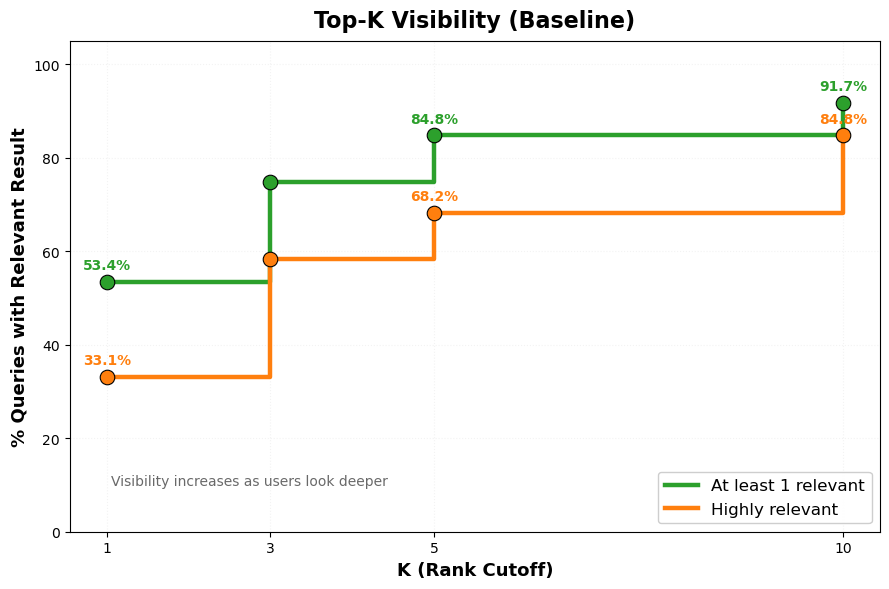

Saved: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\poster_plots\poster_topk_visibility_curve.png


In [ ]:
# Poster Plot: Top-K Visibility Curve
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PHASE9_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'phase9_robustness'
POSTER_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'poster_plots'
POSTER_OUTPUT.mkdir(parents=True, exist_ok=True)

sens_file = PHASE9_OUTPUT / 'phase9_threshold_sensitivity.csv'
sens_df = pd.read_csv(sens_file)

# Keep MQ2007 only
if sens_df['dataset'].dtype == object:
    plot_df = sens_df[sens_df['dataset'] == '2007'].copy()
else:
    plot_df = sens_df[sens_df['dataset'] == 2007].copy()

# Visibility = 100 - Failure %
plot_df['visibility_pct'] = 100 - plot_df['pct_failures']

fig, ax = plt.subplots(figsize=(9, 6))

plot_specs = [
    (1, 'At least 1 relevant', '#2ca02c'),   # green
    (2, 'Highly relevant', '#ff7f0e')        # orange
]

for rel_thresh, label, color in plot_specs:
    sub = plot_df[plot_df['relevance_threshold'] == rel_thresh].sort_values('k')

    ax.step(
        sub['k'],
        sub['visibility_pct'],
        where='post',
        linewidth=3.2,
        label=label,
        color=color
    )

    ax.scatter(
        sub['k'],
        sub['visibility_pct'],
        s=110,
        color=color,
        edgecolors='black',
        linewidths=0.8,
        zorder=3
    )

    # Label only the most important K values to avoid clutter
    for _, row in sub.iterrows():
        if row['k'] in [1, 5, 10]:
            ax.annotate(
                f"{row['visibility_pct']:.1f}%",
                (row['k'], row['visibility_pct']),
                textcoords='offset points',
                xytext=(0, 9),
                ha='center',
                fontsize=10,
                fontweight='bold',
                color=color
            )

ax.set_xlabel('K (Rank Cutoff)', fontsize=13, fontweight='bold')
ax.set_ylabel('% Queries with Relevant Result', fontsize=13, fontweight='bold')
ax.set_title('Top-K Visibility (Baseline)', fontsize=16, fontweight='bold', pad=10)

ax.set_xticks([1, 3, 5, 10])
ax.set_ylim(0, 105)

ax.grid(alpha=0.15, linestyle=':')
ax.legend(fontsize=12, loc='lower right', framealpha=0.95)

# Optional: small note inside plot
ax.text(
    1.05,
    10,
    'Visibility improves with K, but users rarely go beyond top-5',
    fontsize=10,
    color='dimgray'
)

plt.tight_layout()

output_path = POSTER_OUTPUT / 'poster_topk_visibility_curve.png'
plt.savefig(output_path, dpi=220, bbox_inches='tight')
plt.show()

print("Saved:", output_path)

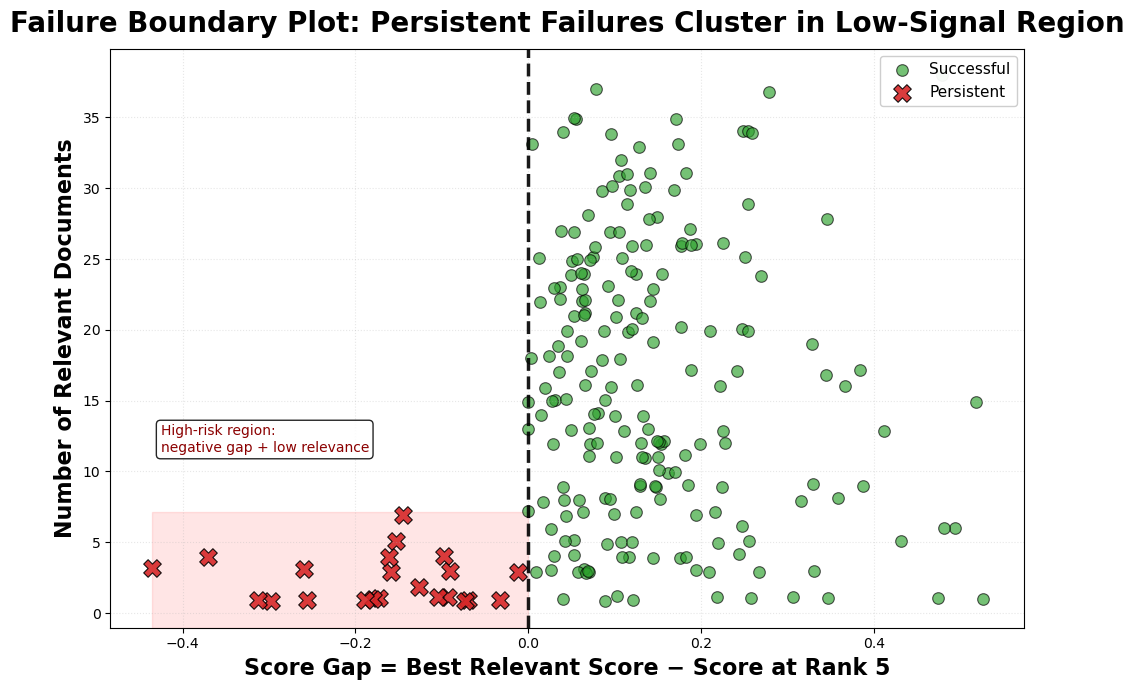

Saved: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\poster_plots\poster_failure_boundary_plot.png


In [15]:
# Poster Plot: Failure Boundary Plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product

PROJECT_ROOT = Path.cwd().parent
PHASE6_FOLDS_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'phase6_models_folds'
POSTER_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'poster_plots'
POSTER_OUTPUT.mkdir(parents=True, exist_ok=True)

FOLD = 'Fold1'
DATASET = '2007'
BASELINE_KEY = 'pointwise_raw_2007'

MODELS = ['pointwise', 'pairwise', 'lightgbm']
PIPELINES = ['raw', 'global', 'per_query']

# Load baseline query metrics and predictions
qm = pd.read_csv(PHASE6_FOLDS_OUTPUT / FOLD / f'{BASELINE_KEY}_query_metrics.csv')
pred = pd.read_csv(PHASE6_FOLDS_OUTPUT / FOLD / f'{BASELINE_KEY}_predictions.csv')

# Robust failure flag parser
def make_fail_flag(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)

    if pd.api.types.is_numeric_dtype(series):
        return series.fillna(0).round().astype(int).clip(0, 1)

    return series.map(
        lambda v: 1 if str(v).strip().lower() in ['true', '1', 'yes'] else 0
    ).fillna(0).astype(int)

# Reconstruct persistent and successful query sets
evaluable_sets = {}
failure_sets = {}

for model, pipeline in product(MODELS, PIPELINES):
    key = f'{model}_{pipeline}_{DATASET}'
    qm_config = pd.read_csv(PHASE6_FOLDS_OUTPUT / FOLD / f'{key}_query_metrics.csv')

    evaluable_sets[key] = set(qm_config.loc[qm_config['num_relevant_1'] > 0, 'qid'])

    fail_flag = make_fail_flag(qm_config['Failure@5_primary'])
    fail_mask = (qm_config['num_relevant_1'] > 0) & (fail_flag == 1)

    failure_sets[key] = set(qm_config.loc[fail_mask, 'qid'])

all_evaluable = set.intersection(*evaluable_sets.values())
persistent_qids = set.intersection(*failure_sets.values())
all_failing = set.union(*failure_sets.values())
successful_qids = all_evaluable - all_failing

# Compute score_gap = best relevant score - score at rank 5
def compute_score_gap(qid):
    q_docs = pred[pred['qid'] == qid].copy()

    if len(q_docs) == 0:
        return np.nan

    q_docs = q_docs.sort_values('score', ascending=False)

    relevant = q_docs[q_docs['label'] >= 1]
    if len(relevant) == 0:
        return np.nan

    best_rel_score = float(relevant['score'].max())

    k_actual = min(5, len(q_docs))
    score_at_rank_5 = float(q_docs.iloc[k_actual - 1]['score'])

    return best_rel_score - score_at_rank_5

# Build plotting dataframe
rows = []

for qid in persistent_qids:
    row = qm[qm['qid'] == qid]
    if len(row) == 0:
        continue

    row = row.iloc[0]

    rows.append({
        'qid': qid,
        'group': 'Persistent',
        'num_relevant_1': int(row['num_relevant_1']),
        'score_gap': compute_score_gap(qid)
    })

for qid in successful_qids:
    row = qm[qm['qid'] == qid]
    if len(row) == 0:
        continue

    row = row.iloc[0]

    rows.append({
        'qid': qid,
        'group': 'Successful',
        'num_relevant_1': int(row['num_relevant_1']),
        'score_gap': compute_score_gap(qid)
    })

plot_df = pd.DataFrame(rows).dropna()

# Add slight y-jitter so integer counts do not overlap too much
rng = np.random.RandomState(36)
plot_df['num_relevant_1_jitter'] = (
    plot_df['num_relevant_1'] + rng.uniform(-0.18, 0.18, len(plot_df))
)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# High-risk shaded region: negative score gap + low relevance
x_min = plot_df['score_gap'].min()
x_pos = x_min + 0.01
y_pos = plot_df['num_relevant_1'].max() * 0.30

ax.axvspan(
    x_min,
    0,
    ymin=0,
    ymax=0.20,
    alpha=0.10,
    color='red'
)

ax.text(
    x_pos,
    y_pos,
    'High-risk region:\nnegative gap + low relevance',
    fontsize=10,
    color='darkred',
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='black',
        alpha=0.85
    )
)

# Scatter points
plot_styles = [
    ('Successful', '#2ca02c', 'o', 70),
    ('Persistent', '#d62728', 'X', 160)
]

for group, color, marker, size in plot_styles:
    sub = plot_df[plot_df['group'] == group]

    ax.scatter(
        sub['score_gap'],
        sub['num_relevant_1_jitter'],
        c=color,
        marker=marker,
        s=size,
        alpha=0.65 if group == 'Successful' else 0.9,
        edgecolors='black',
        linewidths=0.8,
        label=group
    )

# Boundary line
ax.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2.5,
    alpha=0.9
)

# Labels and title
ax.set_xlabel(
    'Score Gap = Best Relevant Score − Score at Rank 5',
    fontsize=16,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Relevant Documents',
    fontsize=16,
    fontweight='bold'
)

ax.set_title(
    'Failure Boundary Plot: Persistent Failures Cluster in Low-Signal Region',
    fontsize=20,
    fontweight='bold',
    pad=12
)

ax.grid(alpha=0.3, linestyle=':')
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)

plt.tight_layout()

output_path = POSTER_OUTPUT / 'poster_failure_boundary_plot.png'
plt.savefig(output_path, dpi=220, bbox_inches='tight')
plt.show()

print("Saved:", output_path)

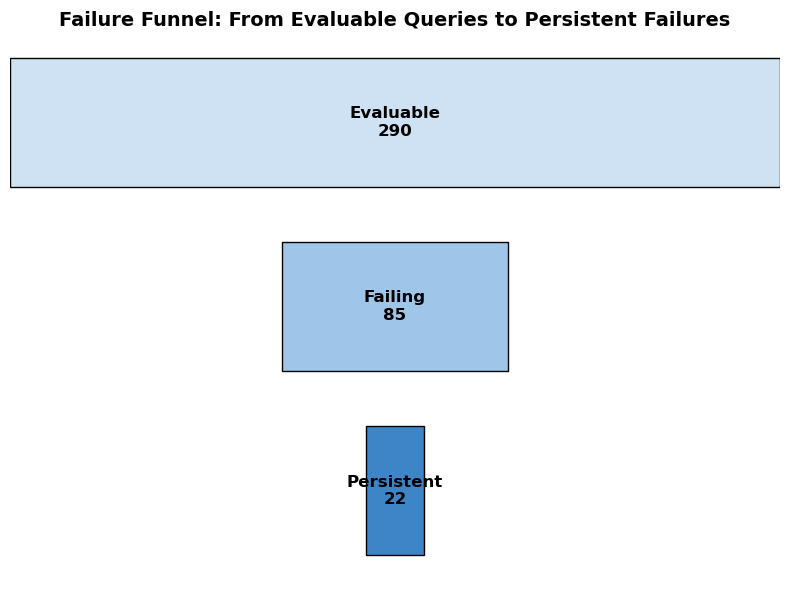

Saved: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\poster_plots\poster_failure_funnel.png


In [16]:
# Optional Poster Plot: Sparsity Funnel
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PHASE8_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'phase8_structural_analysis'
POSTER_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'poster_plots'
POSTER_OUTPUT.mkdir(parents=True, exist_ok=True)

summary_json = PHASE8_OUTPUT / 'phase8_summary.json'

import json
with open(summary_json, 'r') as f:
    s = json.load(f)

stages = ['Evaluable', 'Failing', 'Persistent']
values = [
    s['persistent_count'] + s['non_persistent_count'] + s['successful_count'],
    s['persistent_count'] + s['non_persistent_count'],
    s['persistent_count']
]

fig, ax = plt.subplots(figsize=(8, 6))

max_width = max(values)
y_positions = [2, 1, 0]
colors = ['#cfe2f3', '#9fc5e8', '#3d85c6']

for y, val, label, color in zip(y_positions, values, stages, colors):
    left = (max_width - val) / 2
    ax.barh(y, val, left=left, height=0.7, color=color, edgecolor='black')
    ax.text(max_width / 2, y, f'{label}\n{val}', ha='center', va='center', fontsize=12, fontweight='bold')

ax.set_xlim(0, max_width)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('Failure Funnel: From Evaluable Queries to Persistent Failures', fontsize=14, fontweight='bold')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(POSTER_OUTPUT / 'poster_failure_funnel.png', dpi=180, bbox_inches='tight')
plt.show()

print("Saved:", POSTER_OUTPUT / 'poster_failure_funnel.png')

In [21]:
import pandas as pd
from pathlib import Path
from itertools import product

# Paths
PROJECT_ROOT = Path.cwd().parent
PHASE6_OUTPUT = PROJECT_ROOT / "data" / "processed" / "phase6_models_folds"

# Config
DATASET = "2007"
FOLD = "Fold1"
MODELS = ["pointwise", "pairwise", "lightgbm"]
PIPELINES = ["raw", "global", "per_query"]

def make_fail_flag(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)
    if pd.api.types.is_numeric_dtype(series):
        return series.fillna(0).round().astype(int).clip(0, 1)
    return series.map(lambda v: 1 if str(v).lower() in ["true", "1", "yes"] else 0).astype(int)

# Storage
query_metrics = {}
evaluable_sets = {}
failure_sets = {}

# Load all 9 model × pipeline query_metrics files
for model, pipeline in product(MODELS, PIPELINES):
    key = f"{model}_{pipeline}_{DATASET}"
    file_path = PHASE6_OUTPUT / FOLD / f"{key}_query_metrics.csv"
    
    if not file_path.exists():
        raise RuntimeError(f"Missing file: {file_path}")
    
    qm = pd.read_csv(file_path)
    
    required_cols = ["qid", "num_relevant_1", "Failure@5_primary"]
    for col in required_cols:
        if col not in qm.columns:
            raise RuntimeError(f"Missing column {col} in {file_path}")
    
    query_metrics[key] = qm
    
    # Evaluable = query has at least one relevant doc
    evaluable_sets[key] = set(qm.loc[qm["num_relevant_1"] > 0, "qid"])
    
    # Failing = evaluable AND Failure@5_primary == 1
    fail_flag = make_fail_flag(qm["Failure@5_primary"])
    fail_mask = (qm["num_relevant_1"] > 0) & (fail_flag == 1)
    failure_sets[key] = set(qm.loc[fail_mask, "qid"])

# All queries from baseline file
baseline_key = f"pointwise_raw_{DATASET}"
baseline_qm = query_metrics[baseline_key]

all_queries = set(baseline_qm["qid"])

# Evaluable queries common across all configs
evaluable_queries = set.intersection(*evaluable_sets.values())

# Failing queries = fail in at least one config
failing_queries = set.union(*failure_sets.values())

# Persistent failures = fail in all 9 configs
persistent_failures = set.intersection(*failure_sets.values())

# Summary table
summary_counts = pd.DataFrame({
    "stage": [
        "All queries",
        "Evaluable queries",
        "Failing queries",
        "Persistent failures"
    ],
    "definition": [
        "All test queries in MQ2007 Fold1 baseline file",
        "Queries with num_relevant_1 > 0",
        "Evaluable queries failing in at least one model/pipeline config",
        "Evaluable queries failing across all 9 model/pipeline configs"
    ],
    "count": [
        len(all_queries),
        len(evaluable_queries),
        len(failing_queries),
        len(persistent_failures)
    ],
    "percent_of_all_queries": [
        len(all_queries) / len(all_queries) * 100,
        len(evaluable_queries) / len(all_queries) * 100,
        len(failing_queries) / len(all_queries) * 100,
        len(persistent_failures) / len(all_queries) * 100
    ],
    "percent_of_evaluable_queries": [
        None,
        100,
        len(failing_queries) / len(evaluable_queries) * 100,
        len(persistent_failures) / len(evaluable_queries) * 100
    ]
})

display(summary_counts)

,stage,definition,count,percent_of_all_queries,percent_of_evaluable_queries
0,All queries,All test queries in MQ2007 Fold1 baseline file,336,100.000000,NaN
1,Evaluable queries,Queries with num_relevant_1 > 0,290,86.309524,100.000000
2,Failing queries,Evaluable queries failing in at least one mode...,85,25.297619,29.310345
3,Persistent failures,Evaluable queries failing across all 9 model/p...,22,6.547619,7.586207


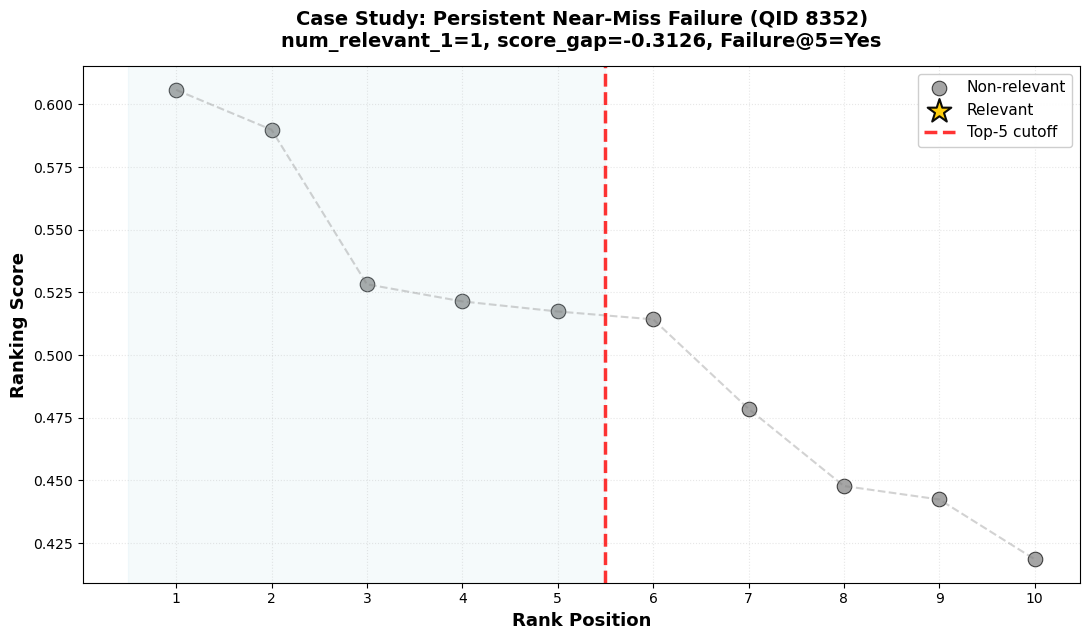

Saved: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\poster_plots\poster_case_study_qid_8352.png


In [22]:
# Poster Plot 4: Case Study Plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PHASE11_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'phase11_case_studies'
POSTER_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'poster_plots'
POSTER_OUTPUT.mkdir(parents=True, exist_ok=True)

summary_df = pd.read_csv(PHASE11_OUTPUT / 'phase11_case_study_queries.csv')
rankings_df = pd.read_csv(PHASE11_OUTPUT / 'phase11_case_study_rankings.csv')

# pick the most negative score gap case
best_qid = summary_df.sort_values('score_gap').iloc[0]['qid']
q_summary = summary_df[summary_df['qid'] == best_qid].iloc[0]
q_rankings = rankings_df[rankings_df['qid'] == best_qid].sort_values('rank').copy()

fig, ax = plt.subplots(figsize=(11, 6.5))

# light connecting line
ax.plot(
    q_rankings['rank'],
    q_rankings['score'],
    linestyle='--',
    linewidth=1.5,
    alpha=0.35,
    color='gray'
)

# non-relevant
non_rel = q_rankings[q_rankings['relevant'] == 0]
ax.scatter(
    non_rel['rank'],
    non_rel['score'],
    s=110,
    alpha=0.70,
    color='#7f7f7f',
    edgecolors='black',
    linewidths=0.8,
    label='Non-relevant'
)

# relevant
rel = q_rankings[q_rankings['relevant'] == 1]
ax.scatter(
    rel['rank'],
    rel['score'],
    s=320,
    alpha=0.95,
    color='#ffcc00',
    marker='*',
    edgecolors='black',
    linewidths=1.5,
    label='Relevant'
)

# top-5 region shading
ax.axvspan(0.5, 5.5, color='lightblue', alpha=0.12)
ax.axvline(5.5, color='red', linestyle='--', linewidth=2.5, alpha=0.8, label='Top-5 cutoff')

# annotate relevant docs
for _, row in rel.iterrows():
    ax.annotate(
        f"Relevant\n(rank {int(row['rank'])})",
        (row['rank'], row['score']),
        textcoords='offset points',
        xytext=(10, 10),
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='yellow', alpha=0.75),
        arrowprops=dict(arrowstyle='->', lw=1.2)
    )

ax.set_xlabel('Rank Position', fontsize=13, fontweight='bold')
ax.set_ylabel('Ranking Score', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.grid(alpha=0.3, linestyle=':')

title = (
    f'Case Study: Persistent Near-Miss Failure (QID {int(best_qid)})\n'
    f'num_relevant_1={int(q_summary["num_relevant_1"])}, '
    f'score_gap={q_summary["score_gap"]:.4f}, '
    f'Failure@5={q_summary["failure_at_5"]}'
)
ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.savefig(POSTER_OUTPUT / f'poster_case_study_qid_{int(best_qid)}.png', dpi=180, bbox_inches='tight')
plt.show()

print("Saved:", POSTER_OUTPUT / f'poster_case_study_qid_{int(best_qid)}.png')

Columns found:
['qid', 'label', 'score']
Number of candidate qids: 20
First 10 candidate qids: [8092, 8137, 8182, 8422, 8463, 8683, 8832, 9012, 9302, 9329]
Selected qids: [8092, 8137]


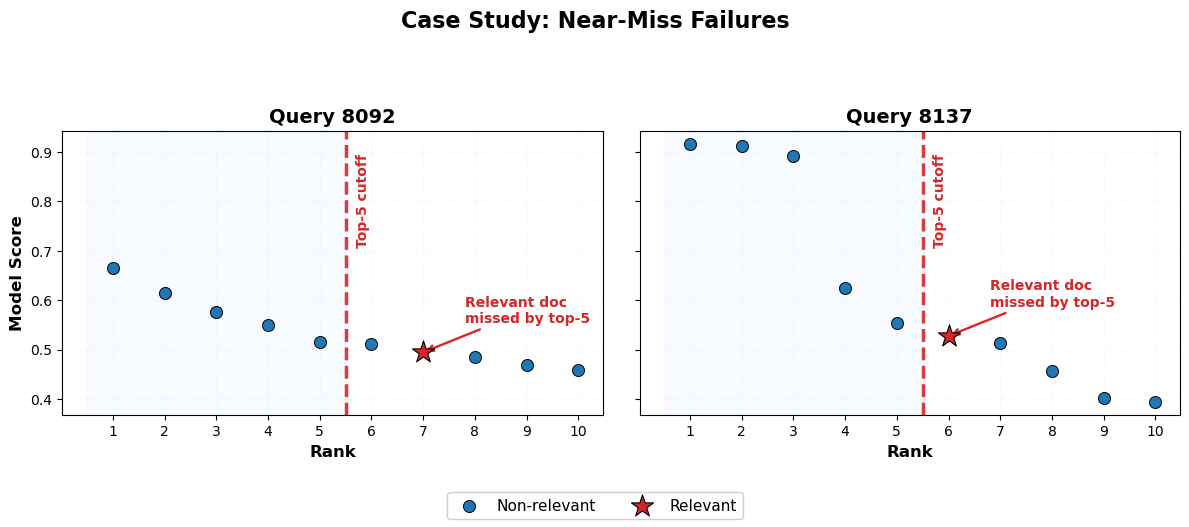

Saved: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\poster_plots\poster_case_study_rankings.png


In [31]:
# Poster Panel 8: Case Study Plot from Baseline Predictions

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PHASE6_FOLDS_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'phase6_models_folds'
POSTER_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'poster_plots'
POSTER_OUTPUT.mkdir(parents=True, exist_ok=True)

FOLD = 'Fold1'
BASELINE_KEY = 'pointwise_raw_2007'

pred_file = PHASE6_FOLDS_OUTPUT / FOLD / f'{BASELINE_KEY}_predictions.csv'
pred = pd.read_csv(pred_file)

print("Columns found:")
print(pred.columns.tolist())

required_cols = ['qid', 'score', 'label']
missing = [col for col in required_cols if col not in pred.columns]

if missing:
    raise ValueError(
        f"Missing columns: {missing}\n"
        f"Available columns are: {pred.columns.tolist()}"
    )

pred = pred.copy()
pred['score'] = pd.to_numeric(pred['score'])
pred['label'] = pd.to_numeric(pred['label'])

# Rank documents within each query by descending model score
pred = pred.sort_values(['qid', 'score'], ascending=[True, False])
pred['rank'] = pred.groupby('qid').cumcount() + 1

top10 = pred[pred['rank'] <= 10].copy()

# Find queries where relevant document is missed by top 5 but appears in top 10
candidate_qids = []

for qid, group in top10.groupby('qid'):
    has_relevant_top5 = ((group['label'] >= 1) & (group['rank'] <= 5)).any()
    has_relevant_6_to_10 = ((group['label'] >= 1) & (group['rank'] > 5)).any()

    if (not has_relevant_top5) and has_relevant_6_to_10:
        candidate_qids.append(qid)

print("Number of candidate qids:", len(candidate_qids))
print("First 10 candidate qids:", candidate_qids[:10])

if len(candidate_qids) < 2:
    raise ValueError(
        "Still fewer than 2 suitable examples found.\n"
        "Send me the printed candidate count and first qids."
    )

selected_qids = candidate_qids[:2]
print("Selected qids:", selected_qids)

# Plot two examples
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, qid in zip(axes, selected_qids):
    q = top10[top10['qid'] == qid].sort_values('rank').copy()

    nonrel = q[q['label'] == 0]
    rel = q[q['label'] >= 1]

    # Shade visible top-5 area
    ax.axvspan(0.5, 5.5, color='#eaf3ff', alpha=0.35)

    ax.scatter(
        nonrel['rank'],
        nonrel['score'],
        s=75,
        color='#1f77b4',
        edgecolors='black',
        linewidths=0.7,
        label='Non-relevant',
        zorder=3
    )

    ax.scatter(
        rel['rank'],
        rel['score'],
        s=280,
        color='#d62728',
        marker='*',
        edgecolors='black',
        linewidths=0.8,
        label='Relevant',
        zorder=5
    )

    ax.axvline(
        5.5,
        color='#d62728',
        linestyle='--',
        linewidth=2.5,
        alpha=0.9
    )

    ax.text(
    5.7,
    0.92,
    'Top-5 cutoff',
    transform=ax.get_xaxis_transform(),
    color='#d62728',
    fontsize=10,
    fontweight='bold',
    rotation=90,
    va='top'

    )

    rel_after_cutoff = rel[rel['rank'] > 5].sort_values('rank')

    if len(rel_after_cutoff) > 0:
        target = rel_after_cutoff.iloc[0]

        ax.annotate(
            'Relevant doc\nmissed by top-5',
            xy=(target['rank'], target['score']),
            xytext=(target['rank'] + 0.8, target['score'] + 0.06),
            arrowprops=dict(
                arrowstyle='->',
                color='#d62728',
                lw=1.7
            ),
            fontsize=10,
            color='#d62728',
            fontweight='bold'
        )

    ax.set_title(f'Query {qid}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Rank', fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 11))
    ax.grid(alpha=0.15, linestyle=':')

axes[0].set_ylabel('Model Score', fontsize=12, fontweight='bold')

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    fontsize=11,
    framealpha=0.95
)

fig.suptitle(
    'Case Study: Near-Miss Failures',
    fontsize=16,
    fontweight='bold',
    y=1.03
)

plt.tight_layout(rect=[0, 0.10, 1, 0.94])

output_path = POSTER_OUTPUT / 'poster_case_study_rankings.png'
plt.savefig(output_path, dpi=220, bbox_inches='tight')
plt.show()

print("Saved:", output_path)

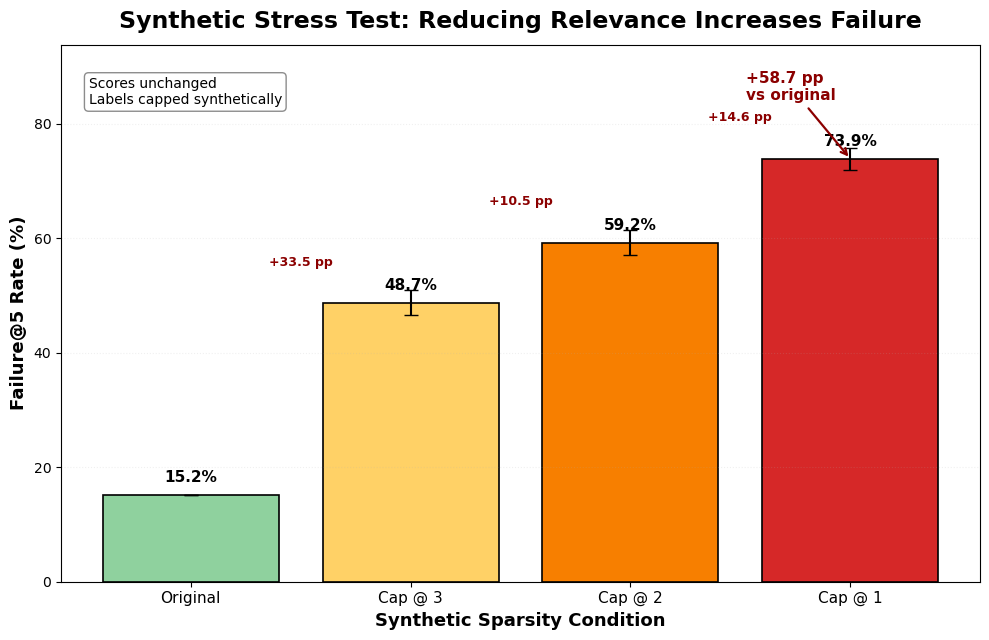

Saved: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\poster_plots\poster_synthetic_stress_test.png


In [37]:
# Poster Plot 5: Synthetic Stress Test - final version with increments between bars

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PHASE12_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'phase12_synthetic_stress'
POSTER_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'poster_plots'
POSTER_OUTPUT.mkdir(parents=True, exist_ok=True)

summary_df = pd.read_csv(PHASE12_OUTPUT / 'phase12_sparsity_stress_summary.csv')

level_order = ['original', 'cap_rel_3', 'cap_rel_2', 'cap_rel_1']
summary_df['sparsity_level'] = pd.Categorical(
    summary_df['sparsity_level'],
    categories=level_order,
    ordered=True
)

summary_df = summary_df.sort_values('sparsity_level').reset_index(drop=True)

x = np.arange(len(summary_df))
y = summary_df['mean_failure_pct'].values
yerr = summary_df['std_failure_rate'].values * 100

colors = ['#8fd19e', '#ffd166', '#f77f00', '#d62828']

fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.bar(
    x,
    y,
    yerr=yerr,
    capsize=5,
    color=colors,
    edgecolor='black',
    linewidth=1.2
)

# Bar value labels
for i, row in summary_df.iterrows():
    ax.annotate(
        f'{row["mean_failure_pct"]:.1f}%',
        (x[i], y[i]),
        textcoords='offset points',
        xytext=(0, 9),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Incremental gains between bars
for i in range(1, len(y)):
    diff = y[i] - y[i - 1]

    x_mid = (x[i - 1] + x[i]) / 2
    y_mid = max(y[i - 1], y[i]) + 6

    ax.text(
        x_mid,
        y_mid,
        f'+{diff:.1f} pp',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='darkred'
    )

# Final increase annotation only
orig = summary_df.iloc[0]['mean_failure_pct']
last = summary_df.iloc[-1]['mean_failure_pct']
delta = last - orig

ax.annotate(
    f'+{delta:.1f} pp\nvs original',
    xy=(x[-1], y[-1]),
    xytext=(-75, 42),
    textcoords='offset points',
    fontsize=11,
    fontweight='bold',
    color='darkred',
    arrowprops=dict(
        arrowstyle='->',
        lw=1.6,
        color='darkred'
    )
)

# Small method note
ax.text(
    0.03,
    0.94,
    'Scores unchanged\nLabels capped synthetically',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=10,
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='gray',
        alpha=0.9
    )
)

ax.set_xticks(x)
ax.set_xticklabels(
    ['Original', 'Cap @ 3', 'Cap @ 2', 'Cap @ 1'],
    fontsize=11
)

ax.set_xlabel('Synthetic Sparsity Condition', fontsize=13, fontweight='bold')
ax.set_ylabel('Failure@5 Rate (%)', fontsize=13, fontweight='bold')

ax.set_title(
    'Synthetic Stress Test: Reducing Relevance Increases Failure',
    fontsize=17,
    fontweight='bold',
    pad=12
)

ax.grid(axis='y', alpha=0.18, linestyle=':')
ax.set_ylim(0, max(y + yerr) + 18)

plt.tight_layout()

output_path = POSTER_OUTPUT / 'poster_synthetic_stress_test.png'
plt.savefig(output_path, dpi=220, bbox_inches='tight')
plt.show()

print("Saved:", output_path)